**Copyright © 2023, Abhishek Hanchate, Satish T.S. Bukkapatnam, and Smart Manufacturing Advanced Research Team, Texas A&M University, All rights reserved.**

In [ ]:
__author__ = "Abhishek Hanchate"
__copyright__ = "Copyright (C) 2023 Abhishek Hanchate"
__version__ = "1.0"

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import io
from google.colab import files
datapath = '/content/drive/My Drive/Ph. D. Research/CESMII Project/UTRGV-DL/'

In [ ]:
# Load libraries
import numpy as np
from keras.preprocessing.text import Tokenizer
from keras import models
from keras import layers
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
# Set random seed
np.random.seed(0)

In [ ]:
import tensorflow as tf
import os
import sys
stderr = sys.stderr
sys.stderr = open(os.devnull, 'w')
import keras
sys.stderr = stderr
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.metrics import BinaryAccuracy
from keras.callbacks import LearningRateScheduler

In [ ]:
import matplotlib as mpl
import os
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
mpl.rcParams['font.family'] = 'Avenir'
plt.rcParams['font.size'] = 18
plt.rcParams['axes.linewidth'] = 2
import plotly.offline as py
import plotly.graph_objs as go
import cv2
import glob
import time
import datetime
import math

In [ ]:
import numpy as np
from scipy import signal
import scipy.io.wavfile as wav
from numpy.lib import stride_tricks
import matplotlib.pyplot as plt

""" short time fourier transform of audio signal """
def stft(sig, frameSize, overlapFac=0.5, window=np.hanning):
    win = window(frameSize)
    hopSize = int(frameSize - np.floor(overlapFac * frameSize))
    
    # zeros at beginning (thus center of 1st window should be for sample nr. 0)
    samples = np.append(np.zeros(np.int64(np.floor(frameSize/2.0))), sig)    
    # cols for windowing
    cols = np.int64(np.ceil( (len(samples) - frameSize) / float(hopSize)) + 1)
    # zeros at end (thus samples can be fully covered by frames)
    samples = np.append(samples, np.zeros(frameSize))
    
    frames = stride_tricks.as_strided(
            samples, shape=(cols, frameSize),
            strides=(samples.strides[0]*hopSize, samples.strides[0])).copy()
    frames *= win
    
    return np.fft.rfft(frames)    
    
""" scale frequency axis logarithmically """    
def logscale_spec(spec, sr=44100, factor=20.):
    timebins, freqbins = np.shape(spec)

    scale = np.linspace(0, 1, freqbins) ** factor
    scale *= (freqbins-1)/max(scale)
    scale = np.unique(np.round(scale))
    scale = np.int64(scale)
    
    # create spectrogram with new freq bins
    newspec = np.complex128(np.zeros([timebins, len(scale)]))
    for i in range(0, len(scale)):
        if i == len(scale)-1:
            newspec[:,i] = np.sum(spec[:,scale[i]:], axis=1)
        else:        
            newspec[:,i] = np.sum(spec[:,scale[i]:scale[i+1]], axis=1)
    
    # list center freq of bins
    allfreqs = np.abs(np.fft.fftfreq(freqbins*2, 1./sr)[:freqbins+1])
    freqs = []
    for i in range(0, len(scale)):
        if i == len(scale)-1:
            freqs += [np.mean(allfreqs[scale[i]:])]
        else:
            freqs += [np.mean(allfreqs[scale[i]:scale[i+1]])]
    
    return newspec, freqs

""" plot spectrogram"""
def plotstft(samples, samplerate, binsize=2**10, 
        plotpath=None, colormap="jet", plot_artifacts=True):
    
    font = {'family': 'Calibri',
        'color':  'black',
        'weight': 'bold',
        'size': 28,
        }   

    s = stft(samples, binsize)
    
    sshow, freq = logscale_spec(s, factor=1.0, sr=samplerate)
    ims = 20.*np.log10(np.abs(sshow)/10e-6) # amplitude to decibel
    #ims = (np.abs(sshow))**(1/100) # amplitude to decibel
    
    timebins, freqbins = np.shape(ims)
    
    plt.figure(figsize=(15, 7.5))
    plt.imshow(np.transpose(ims), origin="lower", 
            aspect="auto", cmap=colormap, interpolation="none", vmin=25, vmax=125)
    # vmin = -0, vmax = 100
    if not plot_artifacts:
      plt.axis('off')
    else:
      plt.colorbar()
      plt.xlabel("Time (Sec)", fontdict = font)
      plt.ylabel("Frequency (Hz)", fontdict = font)
      plt.xlim([0, timebins-1])
      plt.ylim([0, freqbins])

      xlocs = np.float32(np.linspace(0, timebins-1, 5))
      plt.xticks(xlocs, ["%.02f" % l for l in 
          ((xlocs*len(samples)/timebins)+(0.5*binsize))/samplerate], fontsize = 24, fontweight = 'bold')

      ylocs = np.int16(np.round(np.linspace(0, freqbins-1, 10)))
      plt.yticks(ylocs, ["%.02f" % freq[i] for i in ylocs], fontsize = 24, fontweight = 'bold')
    
    if plotpath:
        plt.savefig(plotpath, bbox_inches="tight")
    else:
        plt.show()
    plt.clf()

In [ ]:
import pandas as pd
data11 = pd.read_excel(datapath + 'CESMII220512/Experiment 1-Trial 1.xlsx')
print(data11.head(10))

In [ ]:
print(data11.head(20))

In [ ]:
len(data11)

1048575

In [ ]:
print(pd.DataFrame(data11).head(20))

In [ ]:
dff = data11.loc[3:]   # dff = data11.loc[3:]  # dff = data11.loc[15:]
dff = dff.iloc[:, 1]   # dff = dff.iloc[:, 1]  # dff = dff.iloc[:, 1]

In [ ]:
rate = data11.iloc[0, 1]
rate

6.25e-06

In [ ]:
rate = 1 / rate
rate

160000.0

In [ ]:
from matplotlib.pyplot import figure
import matplotlib.font_manager
font = {'family': 'Arial',
        'color':  'black',
        'weight': 'bold',
        'size': 38,
        }   
figure(figsize=(25, 13)) # 25, 13
plt.plot(dff, linewidth = 2.5)
plt.title('Experiment 1, Trial 1', fontdict = font)
plt.xlabel('Sample Points', fontdict = font)
plt.ylabel('Amplitude (Volts)', fontdict = font)
plt.xticks(fontsize = 34, fontweight = 'bold')
plt.yticks(fontsize = 34, fontweight = 'bold')
plt.grid()
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 2.5
plt.rcParams["figure.figsize"] = (25, 13)
#plt.ylim([-0.2, 0.2])
#plt.xlim([0, 81920])
#plt.savefig(datapath + 'acc_timedomain.png', dpi = 330)

In [ ]:
plt.plot(dff)

In [ ]:
160000 / 1250

128.0

In [ ]:
dff1 = []
for i in range(0, len(dff), 128):
    dff1.append(dff.iloc[i])

In [ ]:
len(dff1)

8192

In [ ]:
8192 / 1250

6.5536

In [ ]:
1048575 / 160000

6.55359375

In [ ]:
dff1 = dff1[:2000]

In [ ]:
dff1 = dff1 - np.mean(dff1)

In [ ]:
dff = dff - np.mean(dff)

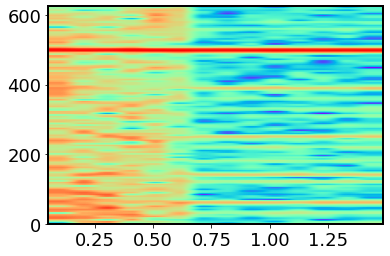

In [ ]:
f = plt.figure()
_ = plt.specgram(dff, Fs=1250, cmap="rainbow") # 160000
_ = plt.axis('on')
#_ = plt.ylim([0, 5000])
#_ = plt.xlim([0, 1])
#_ = plt.close()

In [ ]:
dff = dff[:160000]

In [ ]:
f_acc, t_acc, Sxx_acc = signal.spectrogram(dff, fs = 160000, window = signal.windows.hamming(160000), nperseg = 160000, noverlap = 80000, nfft = 160000, axis = 0)

In [ ]:
print(Sxx_acc.shape)

(80001, 1)


In [ ]:
final_acc = pd.DataFrame(Sxx_acc).iloc[:,0:1].mean(axis = 1)

In [ ]:
font = {'family': 'calibri',
        'color':  'black',
        'weight': 'bold',
        'size': 28,
        }
figure(figsize=(18, 12))
plt.plot(final_acc, linewidth = 3)
plt.title("Experiment 1 Trial 1 Frequency Spectra", fontdict = font)
plt.xlabel("Frequency (Hz)", fontdict=font)
plt.ylabel("Amplitude", fontdict=font)

plt.xticks(fontsize = 24, fontweight = 'bold')
plt.yticks(fontsize = 24, fontweight = 'bold')
plt.grid()
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 2.5
plt.rcParams["figure.figsize"] = (18, 12)

plt.ylim(-0.05e-08,  1e-08)
plt.xlim(0, 625)

In [ ]:
import pandas as pd
data31 = pd.read_excel(datapath + 'CESMII220517/Experiment 3-Trial 1.xlsx')
print(data31.head(10))

      Timestamp 2022-05-17 12:22:48
0      Interval            0.000006
1  Channel name             Input 0
2          Unit                   V
3             0           -0.002682
4      0.000006            0.003138
5      0.000013            0.009617
6      0.000019            0.008203
7      0.000025            0.012511
8      0.000031            0.007808
9      0.000037            0.003369


In [ ]:
f = plt.figure()
_ = plt.specgram(dff, Fs=160000, cmap="rainbow") # 160000
_ = plt.axis('on')
_ = plt.ylim([25000, 30000])

f = plt.figure()
_ = plt.specgram(dff, Fs=160000, cmap="rainbow") # 160000
_ = plt.axis('on')
_ = plt.ylim([20000, 25000])

f = plt.figure()
_ = plt.specgram(dff, Fs=160000, cmap="rainbow") # 160000
_ = plt.axis('on')
_ = plt.ylim([15000, 20000])

f = plt.figure()
_ = plt.specgram(dff, Fs=160000, cmap="rainbow") # 160000
_ = plt.axis('on')
_ = plt.ylim([10000, 15000])

f = plt.figure()
_ = plt.specgram(dff, Fs=160000, cmap="rainbow") # 160000
_ = plt.axis('on')
_ = plt.ylim([5000, 10000])

f = plt.figure()
_ = plt.specgram(dff, Fs=160000, cmap="rainbow") # 160000
_ = plt.axis('on')
_ = plt.ylim([0, 5000])


#_ = plt.xlim([0, 1])

In [ ]:
dff3 = data31.loc[3:]
dff3 = dff3.iloc[:, 1]

In [ ]:
dff3 = dff3 - np.mean(dff3)

In [ ]:
f = plt.figure()
_ = plt.specgram(dff3, Fs=160000, cmap="rainbow")
_ = plt.axis('on')
#_ = plt.ylim([0, 5000])
_ = plt.xlim([0, 1])

In [ ]:
plotstft(dff, 160000, binsize=2**11, plotpath = datapath + f'Spectrograms/spectro_trial.png', \
                    colormap="rainbow", plot_artifacts=False)

<Figure size 1080x540 with 0 Axes>

In [ ]:
#%% Datasets 1
starttime = time.time()
rates = []
datasets = list()
for i in range(1, 21):
    data = pd.read_excel(datapath + f'CESMII220512/Experiment 1-Trial {i}.xlsx')
    df = data.loc[3:] 
    df = df.iloc[:, 1]
    rate = data.iloc[4, 0]
    rate = 1 / rate
    datasets.append(df)
    rates.append(rate)
    f = plt.figure()
    _ = plt.plot(df)
    f.savefig(datapath + f'9thOct_CNN_Model/time_domain_{i}.png')
    _ = plt.close()
endtime = time.time()
print("\n")
print("It took", endtime - starttime, "seconds for", i, "files")



It took 934.2957234382629 seconds for 20 files


In [ ]:
pd.DataFrame(datasets).to_pickle(datapath + 'CESMII220512/Experiment 1-Trial datasets.pkl')

In [ ]:
pd.DataFrame(rates).to_pickle(datapath + 'CESMII220512/Experiment 1-Trial rates.pkl')

In [ ]:
len(datasets)

20

In [ ]:
datasets[0]

In [ ]:
#%% Datasets 1
starttime = time.time()
datasets = pd.read_pickle(datapath + 'CESMII220512/Experiment 1-Trial datasets.pkl')
for i in range(1, 21):
    data = datasets.iloc[i-1]
    f = plt.figure()
    _ = plt.plot(data)
    f.savefig(datapath + f'9thOct_CNN_Model/time_domain_1{i}.png')
    _ = plt.close()
endtime = time.time()
print("\n")
print("It took", endtime - starttime, "seconds for", i, "files")



It took 7.202406167984009 seconds for 20 files


In [ ]:
# Loading Pickle Files - 29th Sept 2022
data = pd.read_pickle(datapath + 'Experiment 1-4 datasets.pkl')
rates = pd.read_pickle(datapath + 'Experiment 1-4 rates.pkl')

In [ ]:
data

In [ ]:
datasets = data

In [ ]:
datasets.iloc[79, :]

3          0.009683
4          0.009551
5          0.005769
6          0.000935
7         -0.002880
             ...   
1048570   -0.006168
1048571   -0.004688
1048572   -0.010542
1048573   -0.013601
1048574   -0.015738
Name: 2022-05-18 14:35:25, Length: 1048572, dtype: float64

In [ ]:
#%% Datasets All
starttime = time.time()
for i in range(1, 81):
    data = datasets.iloc[i-1, :]
    f = plt.figure()
    _ = plt.plot(data)
    f.savefig(datapath + f'9thOct_CNN_Model/time_domain_plot_{i}.png')
    _ = plt.close()
endtime = time.time()
print("\n")
print("It took", endtime - starttime, "seconds for", i, "files")



It took 25.26375651359558 seconds for 80 files


In [ ]:
for i in range(len(datasets)):
  mean = np.mean(datasets.iloc[i, :])
  datasets.iloc[i, :] = datasets.iloc[i, :] - mean

In [ ]:
data = datasets.iloc[0, :]
f_acc, t_acc, Sxx_acc = signal.spectrogram(data, fs = 160000, window = signal.windows.hamming(160000), nperseg = 160000, noverlap = 80000, nfft = 160000, axis = 0)
print(Sxx_acc.shape)
final_acc = pd.DataFrame(Sxx_acc).iloc[:,0:1].mean(axis = 1)

(80001, 12)


In [ ]:
Sxx_acc.shape[1]

12

In [ ]:
#%% Datasets All
starttime = time.time()
for i in range(1, 81):
    data = datasets.iloc[i-1, :]
    f_acc, t_acc, Sxx_acc = signal.spectrogram(data, fs = 160000, window = signal.windows.hamming(160000), nperseg = 160000, noverlap = 80000, nfft = 160000, axis = 0)
    print(Sxx_acc.shape)
    final_acc = pd.DataFrame(Sxx_acc).iloc[:,0:Sxx_acc.shape[1]].mean(axis = 1)
    f = plt.figure()
    font = {'family': 'calibri',
        'color':  'black',
        'weight': 'bold',
        'size': 28,
        }
    _ = plt.plot(final_acc, linewidth = 3)
    _ = plt.title(f"Experiment Trial {i} Frequency Spectra", fontdict = font)
    _ = plt.xlabel("Frequency (Hz)", fontdict=font)
    _ = plt.ylabel("Amplitude", fontdict=font)
    _ = plt.xticks(fontsize = 24, fontweight = 'bold')
    _ = plt.yticks(fontsize = 24, fontweight = 'bold')
    _ = plt.grid()
    _ = plt.rcParams["axes.edgecolor"] = "black"
    _ = plt.rcParams["axes.linewidth"] = 2.5
    _ = plt.rcParams["figure.figsize"] = (18, 12)
    f.savefig(datapath + f'9thOct_CNN_Model/freq_domain_plot_{i}.png')
    _ = plt.close()
endtime = time.time()
print("\n")
print("It took", endtime - starttime, "seconds for", i, "files")

In [ ]:
for i in range(1, 81): 
    signal_data = datasets.iloc[i-1, :]
    signal = signal_data[int(len(signal_data) / 2):len(signal_data)]
    f = plt.figure()
    _ = plt.specgram(signal, Fs=160000, cmap="rainbow")
    _ = plt.axis('off')
    f.savefig(datapath + f'9thOct_CNN_Model/spectro_{i}.png')
    _ = plt.close()

In [ ]:
X = []

In [ ]:
# Skip 38 and 39 since issues with Spectrogram
for i in range(40, 81): # 81  # (40, 81)  # (1, 38)
  img = cv2.imread(datapath + f"9thOct_CNN_Model/spectro_{i}.png") 
  X.append(img)
print(X)

In [ ]:
y_data = pd.read_excel(datapath + 'CESMII220512/CESMIIExperiment 1-Calibration.xlsx')
y1 = y_data.Ra
y1 = y1.dropna()
print(pd.DataFrame(y1))

         Ra
0   0.11375
2   0.11600
4   0.13850
6   0.12850
8   0.12500
10  0.09525
12  0.09775
14  0.11000
16  0.11975
18  0.12625
20  0.12225
22  0.09325
24  0.11400
26  0.11925
28  0.10950
30  0.13625
32  0.11875
34  0.09725
36  0.11550
38  0.12375


In [ ]:
y_data = pd.read_excel(datapath + 'CESMII220516/CESMIIExperiment 2-Calibration..xlsx')
y2 = y_data.Ra
y2 = y2.dropna()
print(pd.DataFrame(y2))

          Ra
0     0.0705
2      0.094
4    0.07125
6     0.0685
8    0.07875
10     0.071
12    0.0935
14   0.08225
16   0.07825
18   0.07575
20     0.078
22   0.08475
24    0.0785
26     0.072
28   0.08825
30   0.06975
32   0.07325
34    0.0585
36   0.08025
38   0.08625
43        Rz
44   0.39225
46   0.37775
48    0.5645
50     0.377
52   0.33325
54     0.336
56   0.44325
58   0.40175
60     0.477
62    0.3605
64    0.5955
66    0.4045
68     0.388
70    0.4885
72   0.32625
74    0.4315
76     0.539
78    0.3115
80   0.43575
82   0.41775
86  0.420075
87  0.006284


In [ ]:
y_data = pd.read_excel(datapath + 'CESMII220517/CESMIIExperiment 3-Calibration (2).xlsx')
y3 = y_data.Ra
y3 = y3.dropna()
print(pd.DataFrame(y3))

         Ra
0   0.07250
2   0.07025
4   0.07575
6   0.06850
8   0.06100
10  0.06100
12  0.07500
14  0.07650
16  0.08350
18  0.07500
20  0.10650
22  0.07775
24  0.07250
26  0.09300
28  0.06150
30  0.08475
32  0.08700
34  0.05850
36  0.07700
38  0.07975


In [ ]:
y_data = pd.read_excel(datapath + 'CESMII220518/CESMIIExperiment 4-Calibration.xlsx')
y4 = y_data.Ra
y4 = y4.dropna()
print(pd.DataFrame(y4))

         Ra
0   0.10425
2   0.13450
4   0.11875
6   0.13625
8   0.13300
10  0.13525
12  0.13825
14  0.13800
16  0.11900
18  0.12575
20  0.14775
22  0.12150
24  0.11150
26  0.10350
28  0.09000
30  0.12725
32  0.09550
34  0.10250
36  0.12125
38  0.11900


In [ ]:
y = y1.append(y2)
y = y.append(y3)
y = y.append(y4)
y

0     0.11375
2       0.116
4      0.1385
6      0.1285
8       0.125
       ...   
30    0.12725
32     0.0955
34     0.1025
36    0.12125
38      0.119
Name: Ra, Length: 103, dtype: object

In [ ]:
yy = y.reset_index()
yy

In [ ]:
df_transpose = yy.T

In [ ]:
df_transpose.pop(37)

In [ ]:
df_transpose.pop(38)

In [ ]:
yyy = df_transpose.T
yyy

In [ ]:
y = yyy.Ra
y

In [ ]:
training_images = np.array(X)

In [ ]:
f = plt.figure()
font = {'family': 'calibri',
        'color':  'black',
        'weight': 'bold',
        'size': 28,
        }
_ = plt.plot(y, linewidth = 3)
_ = plt.title(f"Experiment Trials All Ra Values", fontdict = font)
_ = plt.xlabel("Trial Number", fontdict=font)
_ = plt.ylabel("Ra Value", fontdict=font)
_ = plt.xticks(fontsize = 24, fontweight = 'bold')
_ = plt.yticks(fontsize = 24, fontweight = 'bold')
_ = plt.grid()
_ = plt.rcParams["axes.edgecolor"] = "black"
_ = plt.rcParams["axes.linewidth"] = 2.5
_ = plt.rcParams["figure.figsize"] = (18, 12)
_ = plt.ylim([0.08, 0.10])

In [ ]:
# Binary based on 0.095 Ra, above = 1, below = 0

In [ ]:
# from skimage.transform import resize
# width, height = 512, 512
# resized = [resize(i, (width, height)) for i in X]
# training_images = np.array(resized)

In [ ]:
training_images[0]

In [ ]:
from matplotlib import pyplot as plt
plt.imshow(training_images[0], interpolation='nearest')
plt.show()

In [ ]:
X_backup = X
X_backup

In [ ]:
immgg = X[0]
immgg.shape

(864, 1296, 3)

In [ ]:
# cropp = immgg[180:240, :, :]
# cropp.shape

In [ ]:
# Y = []
# for k in range(len(X)):
#   smp = X[k]
#   smpp = smp[180:240, 60:380, :]
#   smp_img = smpp.astype("float32") / 255.0
#   #lab = cv2.cvtColor(smp_img, cv2.COLOR_BGR2HSV) # BGR2HSV
#   Y.append(smp_img)
# print(Y)

In [ ]:
# smp_img = training_images[0].astype("float32") / 255.0
# lab = cv2.cvtColor(smp_img, cv2.COLOR_BGR2LAB)

In [ ]:
# from matplotlib import pyplot as plt
# plt.imshow(cropp, interpolation='nearest')
# plt.show()

In [ ]:
# from matplotlib import pyplot as plt
# plt.imshow(Y[2], interpolation='nearest')
# plt.show()

In [ ]:
# for i in range(1, 79): # 81
#     signal_data = Y[i-1]
#     f = plt.figure()
#     _ = plt.imshow(signal_data, interpolation='nearest')
#     _ = plt.axis('off')
#     f.savefig(datapath + f'29thSept_CNN_Model_2_Aug_Specs/spectro_{i}.png')

In [ ]:
# training_images = np.array(Y) # np.array(Y) 

In [ ]:
y.iloc[0]

0.11374999999999999

In [ ]:
y_bin = []

In [ ]:
for i in range(len(y)):
    if y.iloc[i] >= 0.095:
        y_bin.append(1)
    else:
        y_bin.append(0)

In [ ]:
y_bin

In [ ]:
len(y_bin)

78

In [ ]:
len(y)

78

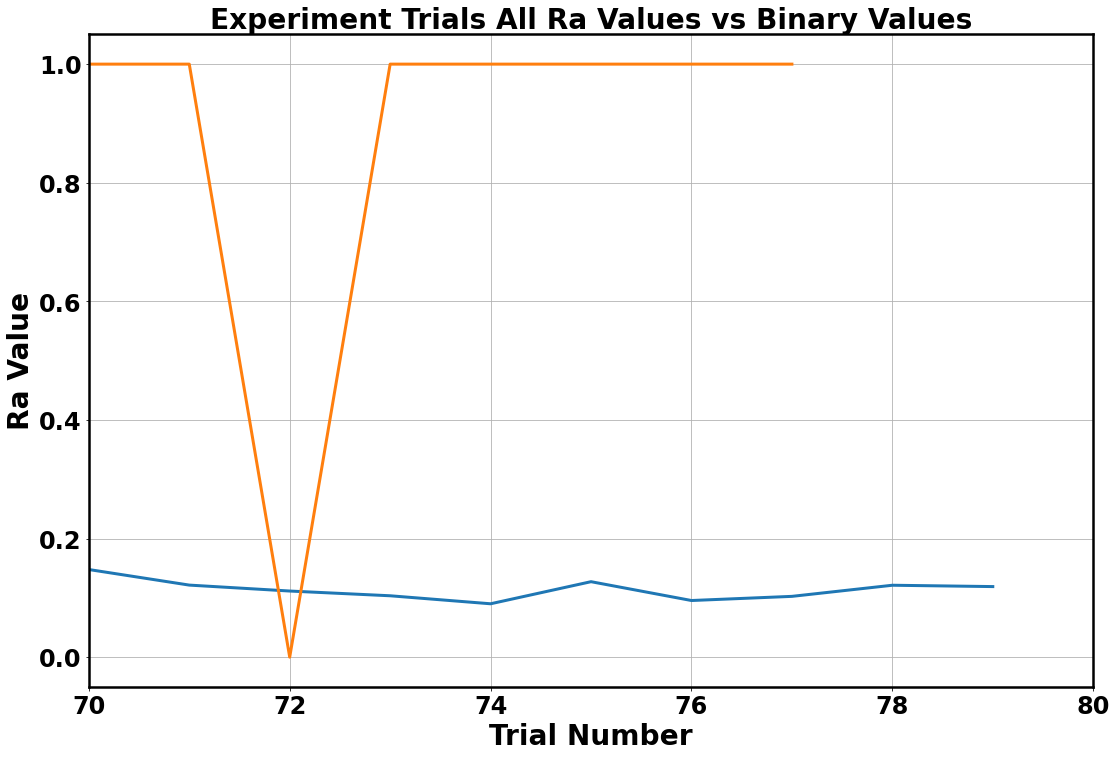

In [ ]:
f = plt.figure()
font = {'family': 'calibri',
        'color':  'black',
        'weight': 'bold',
        'size': 28,
        }
_ = plt.plot(y, linewidth = 3)
_ = plt.plot(y_bin, linewidth = 3)
_ = plt.title(f"Experiment Trials All Ra Values vs Binary Values", fontdict = font)
_ = plt.xlabel("Trial Number", fontdict=font)
_ = plt.ylabel("Ra Value", fontdict=font)
_ = plt.xticks(fontsize = 24, fontweight = 'bold')
_ = plt.yticks(fontsize = 24, fontweight = 'bold')
_ = plt.grid()
_ = plt.rcParams["axes.edgecolor"] = "black"
_ = plt.rcParams["axes.linewidth"] = 2.5
_ = plt.rcParams["figure.figsize"] = (18, 12)
#_ = plt.ylim([0.08, 0.10])
_ = plt.xlim([70, 80])

In [ ]:
y_bin = np.array(y_bin)

In [ ]:
from sklearn.model_selection import train_test_split
X_Train, X_Valid, y_Train, y_Valid = train_test_split(training_images, y_bin, test_size=0.15)

In [ ]:
import tensorflow as tf
import keras
from keras import layers
from keras import models
from keras import utils
from keras.layers import Dense
from keras.models import Sequential
from keras.layers import Flatten
from keras.layers import Dropout
from keras.layers import Activation
from keras.regularizers import l2
from keras import datasets
from keras.callbacks import LearningRateScheduler
from keras.callbacks import History
from keras import losses
from sklearn.utils import shuffle

In [ ]:
print(X_Train)
print(y_Train)
print(X_Valid)
print(y_Valid)

In [ ]:
X_Train.shape[1:]

(864, 1296, 3)

In [ ]:
print(type(X_Train))
print(type(y_Train))
print(type(X_Valid))
print(type(y_Valid))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [ ]:
print(len(X_Train))
print(len(y_Train))
print(len(X_Valid))
print(len(y_Valid))

74
74
4
4


In [ ]:
X_Train.shape

(66, 864, 1296, 3)

In [ ]:
y_Train

In [ ]:
X_Train_backup = X_Train
X_Valid_backup = X_Valid
y_Train_backup = y_Train
y_Valid_backup = y_Valid

In [ ]:
# # Initialize Neural Network model
# # define the model
# m = Sequential()
# m.add(Dense(64, activation="relu", input_shape=X_Train.shape[1:]))
# m.add(Dense(32, activation='relu'))
# m.add(layers.Flatten())
# m.add(Dense(8, activation='relu'))
# m.add(Dense(1, activation='linear'))
# #m.summary()

In [ ]:
# model = tf.keras.models.Sequential()
# model.add(tf.keras.layers.Conv2D(32, kernel_size=(3, 3), activation=tf.nn.relu, input_shape=X_Train.shape[1:]))
# model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
# # model.add(tf.keras.layers.Conv2D(16, kernel_size=(2, 2), activation=tf.nn.relu, input_shape=X_Train.shape[1:]))
# # model.add(tf.keras.layers.MaxPooling2D(pool_size=(1,1)))
# model.add(tf.keras.layers.Flatten()) 
# #model.add(tf.keras.layers.Dense(128, activation = tf.nn.relu, input_shape=X_Train.shape[1:]))
# model.add(tf.keras.layers.Dense(32, activation = tf.nn.relu,))
# model.add(tf.keras.layers.Dense(16, activation = tf.nn.relu))
# model.add(tf.keras.layers.Dense(1, activation = 'linear'))

In [ ]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=X_Train.shape[1:]))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(16, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(32, activation='sigmoid'))
model.add(layers.Dense(1))
model.summary()

In [ ]:
# from keras.callbacks import EarlyStopping
# es = EarlyStopping(monitor='val_loss')

In [ ]:
adam = tf.keras.optimizers.Adam(learning_rate = 0.01, beta_1 = 0.99, beta_2 = 0.999, amsgrad = False)
model.compile(optimizer=adam, loss=tf.keras.losses.BinaryCrossentropy(from_logits=True), metrics=['accuracy'])
history = model.fit(X_Train, y_Train, epochs=100, batch_size = 8, validation_data=(X_Valid, y_Valid), verbose=1)

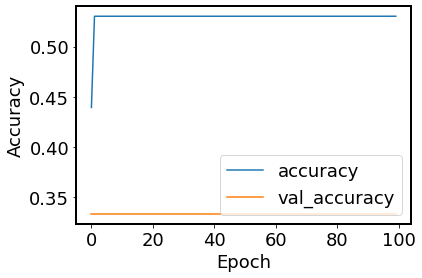

In [ ]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
#plt.ylim([0.5, 1])
plt.legend(loc='lower right')

In [ ]:
acc_per_fold = []
loss_per_fold = []

In [ ]:
# from sklearn.model_selection import KFold
# # Define the K-fold Cross Validator
# kfold = KFold(n_splits=5, shuffle=True)

# # K-fold Cross Validation model evaluation
# fold_no = 1
# for train, test in kfold.split(X_Train, y_Train):

#   # Define the model architecture
#   model = Sequential()
#   model.add(layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=X_Train.shape[1:]))
#   model.add(layers.MaxPooling2D(pool_size=(2, 2)))
#   model.add(layers.Conv2D(64, kernel_size=(3, 3), activation='relu'))
#   model.add(layers.MaxPooling2D(pool_size=(2, 2)))
#   model.add(layers.Flatten())
#   model.add(layers.Dense(32, activation='relu'))
#   model.add(layers.Dense(16, activation='relu'))
#   model.add(layers.Dense(1, activation='softmax'))

#   # Compile the model
#   model.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
#                 optimizer=adam,
#                 metrics=['accuracy'])


#   # Generate a print
#   print('------------------------------------------------------------------------')
#   print(f'Training for fold {fold_no} ...')

#   # Fit data to model
#   history = model.fit(X_Train, y_Train,
#               batch_size=12,
#               epochs=250,
#               verbose=1)

#   # Generate generalization metrics
#   scores = model.evaluate(X_Valid, y_Valid, verbose=0)
#   print(f'Score for fold {fold_no}: {model.metrics_names[0]} of {scores[0]}; {model.metrics_names[1]} of {scores[1]*100}%')
#   acc_per_fold.append(scores[1] * 100)
#   loss_per_fold.append(scores[0])

#   # Increase fold number
#   fold_no = fold_no + 1

In [ ]:
# from keras import optimizers
# # adam = tf.keras.optimizers.Adam(learning_rate = 0.001, beta_1 = 0.99, beta_2 = 0.999, amsgrad = False)
# # adagrad = tf.keras.optimizers.Adagrad(learning_rate=0.001,initial_accumulator_value=0.1,epsilon=1e-07,name="Adagrad")
# # adamax = tf.keras.optimizers.Adamax(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-07,name='Adamax') 
# opt = tf.keras.optimizers.SGD(lr=1e-1, momentum=0.99, decay=1e-2/100)
# model.compile(loss='mae', optimizer=opt, metrics=['mse'])
# history = model.fit(X_Train, y_Train, epochs = 1000, batch_size = 11, validation_data=(X_Valid, y_Valid), shuffle=False, verbose=1, callbacks=[es]) 

In [ ]:
# Epoch 500/500
# 9/9 [==============================] - 1s 118ms/step - loss: 0.0213 - mse: 6.1412e-04 - val_loss: 0.0213 - val_mse: 5.7759e-04

In [ ]:
model1 = tf.keras.models.load_model(datapath + '29thSept_CNN_Model_R2_0.95/29thSept_CNN_Model_2_R2_0.95.h5')

In [ ]:
training_images = np.load(datapath + '29thSept_CNN_Model_R2_0.95/29thSept_CNN_Model_2_R2_0.95_X.npy')

In [ ]:
y_act = np.load(datapath + '29thSept_CNN_Model_R2_0.95/29thSept_CNN_Model_2_R2_0.95_y.npy')

In [ ]:
# make predictions
y_Pred = model1.predict(training_images)
y_Pred

In [ ]:
y

In [ ]:
len(y_act)

78

In [ ]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_act, y_Pred)
mse

2.8695196177064684e-05

In [ ]:
from sklearn.metrics import r2_score
r2_score = r2_score(y_act, y_Pred)
r2_score

0.9506274877693949

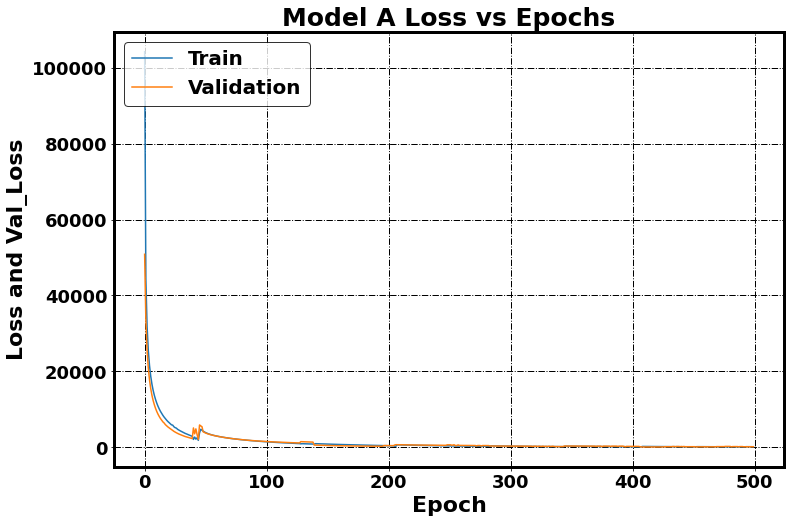

In [ ]:
# summarize history for loss
plt.figure(facecolor='white')
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model A Loss vs Epochs', fontsize=25, fontweight="bold",fontfamily="Arial")
plt.ylabel('Loss and Val_Loss', fontsize=22, fontweight="bold",fontfamily="Arial")
plt.xlabel('Epoch',fontsize= 22, fontweight="bold",fontfamily="Arial")
plt.xticks(fontsize=18,fontfamily="Arial", fontweight="bold")
plt.yticks(fontsize=18,fontfamily="Arial", fontweight="bold")
#plt.xlim([-50, 2050])
#plt.ylim([0, 0.2])

plt.grid(color='black', linestyle='-.', linewidth=1)
plt.rcParams.update({'axes.linewidth': 3})
legend = plt.legend(['Train', 'Validation'], loc='upper left', prop={'size': 20,'family' : 'Arial', 'weight':'bold'})
fig = plt.gcf()
fig.set_size_inches(12, 8, forward=True)
ax = fig.gca()
ax.spines["top"].set_color("black")
ax.spines["left"].set_color("black")
ax.spines["right"].set_color("black")
ax.spines["bottom"].set_color("black")
ax.set_facecolor("white")
frame = legend.get_frame()
frame.set_facecolor('white')
frame.set_edgecolor('black')
plt.show()

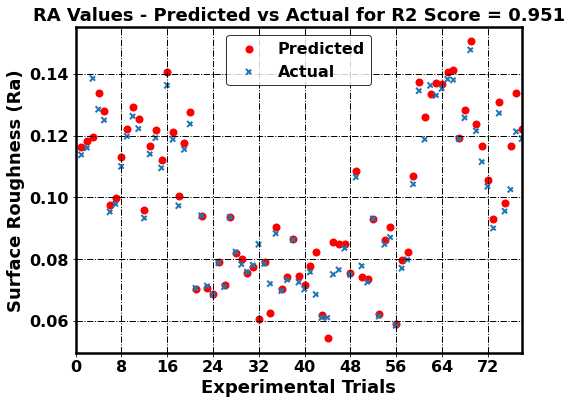

In [ ]:
testlen = 77
from sklearn.metrics import r2_score
plt.figure(facecolor='white')
plt.title('RA Values - Predicted vs Actual for ' + "R2 Score = {:.3f}".format(r2_score(y_act, y_Pred)), fontsize=18, fontweight="bold",fontfamily="Arial")
plt.scatter(np.linspace(1, 78, 78), y_Pred, label = 'Predicted',marker = 'o',color ='r',linewidth=2)
plt.scatter(np.linspace(1, 78, 78), y_act, label = 'Actual',linestyle = '--',marker = 'x',linewidth=2)

plt.xlabel('Experimental Trials', fontsize=18, fontweight="bold",fontfamily="Arial")
plt.ylabel('Surface Roughness (Ra)', fontsize=18, fontweight="bold",fontfamily="Arial")
plt.xticks(np.arange(0, testlen+1, 8),fontsize=16,fontfamily="Arial", fontweight="bold")
plt.yticks(fontsize=16,fontfamily="Arial", fontweight="bold")
plt.xlim([0, testlen+1])

#plt.ylim([0, 400])
plt.grid(color='black',linestyle='-.',linewidth=1)
plt.rcParams.update({'axes.linewidth': 2.5})
plt.legend(loc='upper center',facecolor='white', edgecolor='black', prop={'size': 16,'family' : 'Arial','weight':'bold'})
fig = plt.gcf()
fig.set_size_inches(8,6, forward=True)
ax = fig.gca()
ax.spines["top"].set_color("black")
ax.spines["left"].set_color("black")
ax.spines["right"].set_color("black")
ax.spines["bottom"].set_color("black")
ax.set_facecolor("white")
plt.show()

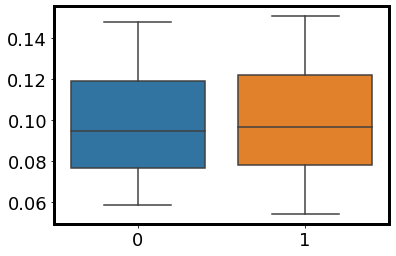

In [ ]:
import numpy as np
import seaborn as sns

all_arr = [y,
           y_Pred]

sns.boxplot(data=all_arr)

In [ ]:
y.shape

(78,)

In [ ]:
y_Pred.shape

(78, 1)

In [ ]:
yy = list(y_act)
len(yy)

78

In [ ]:
yy_Pred = list(y_Pred)
len(yy_Pred)

78

/usr/local/lib/python3.7/dist-packages/matplotlib/cbook/__init__.py:1376: VisibleDeprecationWarning:

Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.



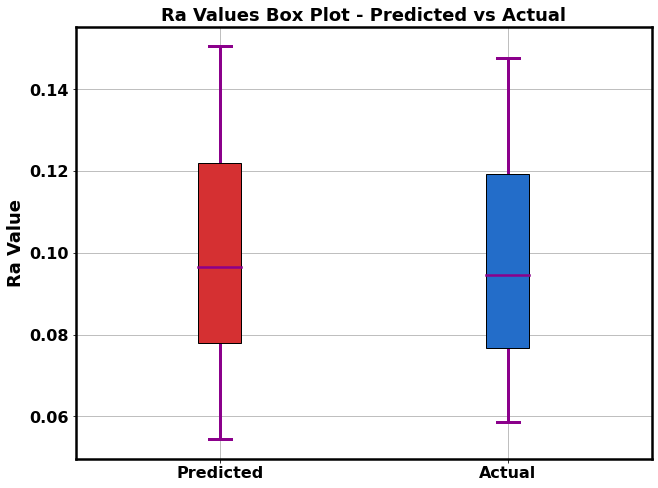

In [ ]:
data = [yy_Pred, yy]                             
f = plt.figure()
font = {'family': 'calibri',
        'color':  'black',
        'weight': 'bold',
        'size': 18,
        }
ax = f.add_axes([0, 0, 1, 1])
bp = ax.boxplot(data, showfliers=True, patch_artist = True)

colors = ['#d53032', '#236dc9'] 
   
for patch, color in zip(bp['boxes'], colors): 
    patch.set_facecolor(color) 

for whisker in bp['whiskers']: 
    whisker.set(color ='#8B008B', linewidth = 3) 
   
for cap in bp['caps']: 
    cap.set(color ='#8B008B', linewidth = 3) 

for median in bp['medians']: 
    median.set(color ='#8B008B', 
               linewidth = 2.5) 
    
_ = plt.title(f"Ra Values Box Plot - Predicted vs Actual", fontdict = font)
#_ = plt.xlabel("Trial Number", fontdict=font)
_ = plt.ylabel("Ra Value", fontdict=font)
_ = plt.xticks(fontsize = 16, fontweight = 'bold')
_ = plt.xticks([1, 2], ['Predicted', 'Actual'])
_ = plt.yticks(fontsize = 16, fontweight = 'bold')
_ = plt.grid()
_ = plt.rcParams["axes.edgecolor"] = "black"
_ = plt.rcParams["axes.linewidth"] = 2.5
_ = plt.rcParams["figure.figsize"] = (8, 6)
#_ = plt.ylim([0.08, 0.10])
#_ = plt.xlim([70, 80])

In [ ]:
model.save(datapath + '29thSept_CNN_Model_2_R2_0.95.h5')

In [ ]:
model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_5 (Conv2D)           (None, 58, 318, 64)       1792      
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 29, 159, 64)      0         
 2D)                                                             
                                                                 
 flatten_5 (Flatten)         (None, 295104)            0         
                                                                 
 dense_10 (Dense)            (None, 64)                18886720  
                                                                 
 dense_11 (Dense)            (None, 1)                 65        
                                                                 
Total params: 18,888,577
Trainable params: 18,888,577
Non-trainable params: 0
__________________________________________

In [ ]:
np.save(datapath + '29thSept_CNN_Model_2_R2_0.95_XTrain', X_Train)
np.save(datapath + '29thSept_CNN_Model_2_R2_0.95_yTrain', y_Train)
np.save(datapath + '29thSept_CNN_Model_2_R2_0.95_XValid', X_Valid)
np.save(datapath + '29thSept_CNN_Model_2_R2_0.95_yValid', y_Valid)

In [ ]:
np.save(datapath + '29thSept_CNN_Model_2_R2_0.95_X', training_images)
np.save(datapath + '29thSept_CNN_Model_2_R2_0.95_y', y)

In [ ]:
np.save(datapath + '29thSept_CNN_Model_2_R2_0.95_Loss', history.history['loss'])
np.save(datapath + '29thSept_CNN_Model_2_R2_0.95_ValLoss', history.history['val_loss'])

In [ ]:
np.save(datapath + '29thSept_CNN_Model_2_R2_0.95_MSE', history.history['mse'])
np.save(datapath + '29thSept_CNN_Model_2_R2_0.95_ValMSE', history.history['val_mse'])

In [ ]:
history.history['val_loss']

In [ ]:
history.history['mse']

In [ ]:
# make predictions
y_Pred = model.predict(X_Valid)
y_Pred

In [ ]:
from sklearn.metrics import r2_score
r2_score = r2_score(y_Valid, y_Pred)
r2_score

0.7836096907893153

In [ ]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_Valid, y_Pred)
mse

0.00015225162047644548

In [ ]:
# Load Model 1 and Preds
model1 = tf.keras.models.load_model(datapath + '28thSept_CNN_Model_4.h5')

In [ ]:
y_Pred1 = model1.predict(training_images)
y_Pred1

In [ ]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y, y_Pred1)
mse

0.0009345477643667235

In [ ]:
from sklearn.metrics import r2_score
r2_score = r2_score(y, y_Pred1)
r2_score

-0.6079684781231789

In [ ]:
model = tf.keras.models.load_model(datapath + '28thSept_CNN_Model.h5')

In [ ]:
!pip install lime

In [ ]:
import lime
import lime.lime_tabular
from lime import lime_image

In [ ]:
explainer = lime_image.LimeImageExplainer()

In [ ]:
y_samp = [0.11375]

In [ ]:
sample = []
for i in range(1, 2): # 81
  img = cv2.imread(datapath + f"Spectrograms/spectro_matplot_{i}.png")
  #imgg = img.flatten()
  sample.append(img)
print(sample)

In [ ]:
from skimage.transform import resize
width, height = 512, 512
resized_sample = [resize(i, (width, height)) for i in sample]
training_images_sample = np.array(resized_sample)

In [ ]:
pred = model.predict(training_images_sample)
pred

array([[0.11465628]], dtype=float32)

In [ ]:
!pip install shap

In [ ]:
import shap

In [ ]:
explainer = shap.DeepExplainer(model = model, data = training_images_sample)
shap_values = explainer.shap_values(training_images_sample)

shap_values = shap_values[0].reshape(-1)
X_test = training_images_sample.reshape(-1)

shap.summary_plot(shap_values, X_test)

In [ ]:
explainer = lime_image.LimeImageExplainer(random_state=123)
explainer

In [ ]:
explanation = explainer.explain_instance(training_images_sample, model.predict(training_images_sample), random_seed=123)
explanation

RuntimeError: ignored

In [ ]:
img, mask = explanation.get_image_and_mask(Y_test[idx], positive_only=True, hide_rest=True)
img.shape, mask.shape

In [ ]:
LX = np.load('markers_dataset_trial/LX.npy')
LY = np.load('markers_dataset_trial/LY.npy')

model = load_model('marker_model_fold_no_10.h5')
pred = model.predict(LX)

LY = np.array([1 if a == 0 else 0 for a in LY])  # reversing 0 and 1

from sklearn.preprocessing import OneHotEncoder
Y_new = OneHotEncoder().fit_transform(LY.reshape((-1,1))).toarray()

pred_class = [1 if a < 0.5 else 0 for a in pred]
correct_X_ind = list(np.where(pred_class==LY)[0])
len(correct_X_ind)

In [ ]:
import lime
from lime import lime_image
from matplotlib import pyplot as plt
fname_out = 'C:\\Users\\data_and_code_Dec31\\Shallow_markers'

seg_fn = 'quickshift'
if seg_fn == 'quickshift':
    k_size = 5   # number of s-pixels
    num_s = 100   # number of perturbed samples
elif seg_fn == 'slic': 
    k_size = 200
    num_s = 400
    
explainer = lime_image.LimeImageExplainer()
score = []
# Input the sample_index corresponding to every image (from 1 to 123)
for sample_ind in correct_X_ind:

# sample_ind = 27
    sample = LX[sample_ind, :, :, :].astype('double')
    y_samp = LY[sample_ind]     # Change accordingly for different seg_fn
    explanation = explainer.explain_instance(sample, model, top_labels=2, hide_color=0, num_samples=num_s, num_features = k_size)
    score.append(explanation.score)

    if explanation.score > 0.75 and explanation.score <= 1:
        temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=False, num_features = k_size, hide_rest=False)
        plt.figure(figsize = (12,8))
        plt.subplot(1, 2, 1)
        plt.imshow(sample)
        plt.subplot(1, 2, 2)
        plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))
        if y_samp == 0:
          plt.suptitle('No marker',fontsize= 14, fontweight = 'bold')
        else:
          plt.suptitle('With marker',fontsize= 14, fontweight = 'bold')
        plt.savefig(fname_out+'\\local results\\'+str(sample_ind)+'_LIME_topten_plot.png',dpi = 400)
        plt.close()

        # save weights and watershed/lime ratios
        weightRatio = []
        for i, e in explanation.local_exp[explanation.top_labels[0]]:
            weightRatio.append((i, e, explanation.local_pred[explanation.top_labels[0]],explanation.intercept[explanation.top_labels[0]],explanation.top_labels[0]))
  
        WR = pd.DataFrame(weightRatio)
        WR.to_csv(fname_out+ str(sample_ind)+'_weightRatioPred_score'+str(round(explanation.score,2))+'_numseg'+str(len(explanation.local_exp[explanation.top_labels[0]]))+'.csv', index = False)
        
            
score = np.array(score)
np.save(fname_out+'\\'+seg_fn+'kerns'+str(k_size)+'_nums'+str(num_s)+'score.npy',score)